# import

In [3]:
import tensorflow as tf
assert tf.__version__.split('.')[0] == '2'
tf.__version__

'2.0.0-alpha0'

In [5]:
from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

%load_ext autoreload
%autoreload 2

In [8]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, features, settings, util

# make dataset

In [7]:
ab = abase.ABase()
ab.load('logmel')

loaded 35/35 (100.00%)


't_a_2'

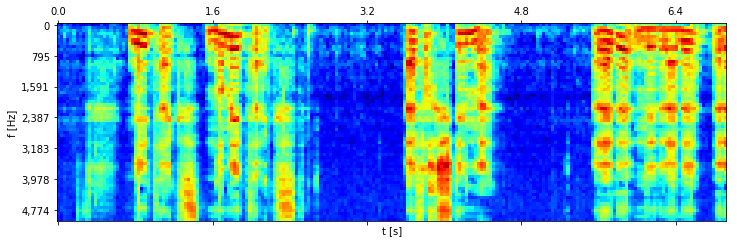

In [15]:
name = ab.sample()
util.plot_logmel(ab.df.loc[name, 'logmel'])
name

In [21]:
ab_train = ab.query('rand_stable > 0.2')
ab_test = ab.query('rand_stable <= 0.2')
print('\n'.join([str(ab_train), str(ab_test)]))

ABase(n=28, series=7, what=o:12|t:12|m:4, who=g:11|p:9|a:8)
ABase(n=7, series=6, what=o:3|t:2|m:1|w:1, who=g:4|a:3)


In [58]:
def make_x_y(df):
    x0 = np.concatenate(list(df.query('what == "t"').logmel.values), axis=0)
    x1 = np.concatenate(list(df.query('what == "o"').logmel.values), axis=0)
    x = np.concatenate([x0, x1])
    y = np.concatenate([
        np.zeros(x0.shape[0], dtype=np.int64),
        np.ones(x1.shape[0], dtype=np.int64),
    ])
    return (
        tf.convert_to_tensor(x),
        tf.one_hot(y, depth=2, dtype=tf.float32),
    )

x, y = make_x_y(ab_train.df)
x_, y_ = make_x_y(ab_test.df)
x.shape, y.shape, x_.shape, y_.shape

(TensorShape([5208, 64]),
 TensorShape([5208, 2]),
 TensorShape([1085, 64]),
 TensorShape([1085, 2]))

# model

In [52]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[64]),
    tf.keras.layers.Dense(units=2, activation='softmax'),
])

model.compile(optimizer=tf.optimizers.SGD(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [57]:
model.fit(x, y, epochs=10, batch_size=10)

dict(zip(
    model.metrics_names,
    model.evaluate(*make_x_y(ab_test.df)),
))

Epoch 1/10
5208/5208 [==============================] - 1s 110us/sample - loss: 0.4563 - accuracy: 0.8013
Epoch 2/10
5208/5208 [==============================] - 1s 131us/sample - loss: 0.4094 - accuracy: 0.8281
Epoch 3/10
5208/5208 [==============================] - 1s 116us/sample - loss: 0.3890 - accuracy: 0.8420
Epoch 4/10
5208/5208 [==============================] - 1s 128us/sample - loss: 0.3767 - accuracy: 0.8439
Epoch 5/10
5208/5208 [==============================] - 1s 121us/sample - loss: 0.3663 - accuracy: 0.8464
Epoch 6/10
5208/5208 [==============================] - 1s 117us/sample - loss: 0.3595 - accuracy: 0.8533
Epoch 7/10
5208/5208 [==============================] - 1s 121us/sample - loss: 0.3515 - accuracy: 0.8529
Epoch 8/10
5208/5208 [==============================] - 1s 115us/sample - loss: 0.3452 - accuracy: 0.8579
Epoch 9/10
5208/5208 [==============================] - 1s 119us/sample - loss: 0.3447 - accuracy: 0.8585
Epoch 10/10
1085/1085 [=======================

{'loss': 0.27855425548443596, 'accuracy': 0.8949309}

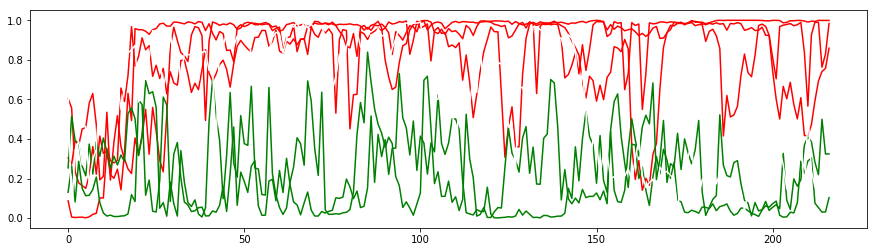

In [79]:
plt.figure(figsize=(15, 4))
cols = {'o': 'r', 't': 'g'}
_ = ab_test
for name in _.df.index:
    plt.plot(model.predict(_.df.loc[name, 'logmel'])[:, 1], cols.get(name[0], 'w'))

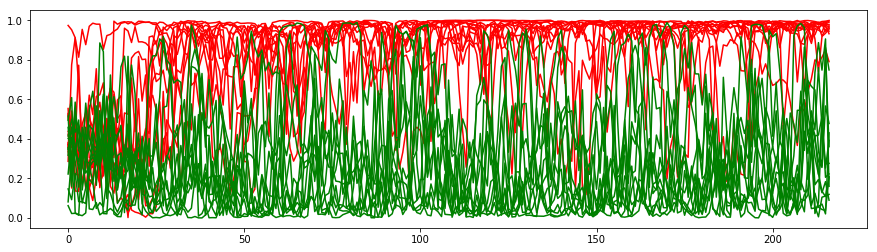

In [81]:
plt.figure(figsize=(15, 4))
_ = ab_train
for name in _.df.index:
    plt.plot(model.predict(_.df.loc[name, 'logmel'])[:, 1], cols.get(name[0], 'w'))

In [59]:
ab_test.df.index

Index(['m_g_1', 'o_a_2', 'o_g_1', 'o_g_3', 't_a_2', 't_g_2', 'w_a_1'], dtype='object', name='name')

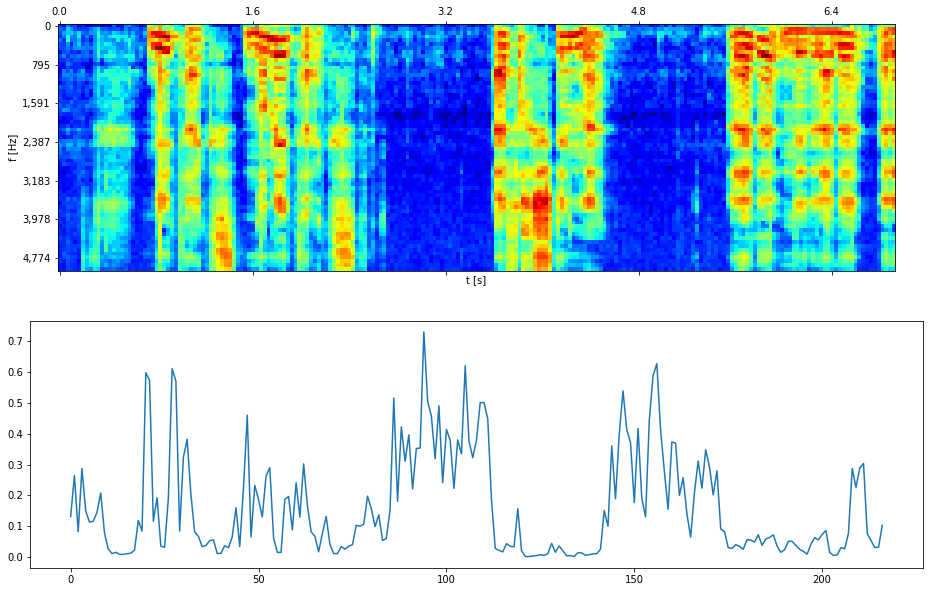

In [70]:
def plot_with_pred(logmel):
    plt.figure(figsize=(16, 10))
    pred = model.predict(logmel)
    util.plot_logmel(logmel, ax=plt.subplot(211))
    plt.subplot(212).plot(pred[:, 1])

plot_with_pred(ab_test.df.loc['t_a_2', 'logmel'])